# Hito 2: “Análisis de canciones de Spotify”

Grupo 17, Sección 2 


**Integrantes:**
- Juan Balboa E.
- Sebastian Cadena A.
- Benjamin Fuentes R.
- Matias Mendez Z.
- Camila Rojas G.



## Introducción

Spotify es una de las plataformas de música más importantes del mundo, con más de 100 millones de canciones y cientos de millones de usuarios. Esta enorme cantidad de datos la convierte en una fuente valiosa para estudiar la música de forma científica. Lo interesante de Spotify es que cada canción tiene características medibles y objetivas como danceability (qué tan bailable es), energy (su nivel de energía), valence (si suena alegre o triste), acousticness (si es acústica o electrónica) e instrumentalness (cuánta música instrumental tiene). Estas características permiten analizar las canciones como datos numéricos y aplicar técnicas de ciencia de datos.

Este trabajo utiliza técnicas de minería de datos para explorar patrones ocultos en estas características acústicas. Específicamente, se busca descubrir si existen grupos naturales de canciones basados en sus propiedades sonoras, predecir la popularidad de las canciones, y determinar si es posible clasificar géneros musicales usando únicamente estas métricas objetivas. Los resultados ayudarán a entender mejor cómo se organiza la música y podrán presentarse como aplicaciones prácticas en sistemas de recomendación para usuarios.


## Exploración de datos

Importar librerías necesarias.

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de visualización para gráficos más atractivos

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Cargar y explorar el dataset.

In [54]:
# Cargar el dataset desde el archivo CSV
df = pd.read_csv('dataset.csv')

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("\nPrimeras 5 filas del dataset:")
df.head()

Dimensiones: 114,000 filas × 21 columnas

Primeras 5 filas del dataset:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Saneamiento de Datos

#### Eliminación columnas con alta cardinalidad

In [55]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name'])
df.head()

,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


#### Normalización de Artistas

In [56]:
df['artists'] = df['artists'].str.split(';')
df = df.explode('artists')
df['artists'] = df['artists'].str.strip()
df=df.reset_index(drop=True)
print(f"Dimensiones después de explotar artistas: {df.shape[0]:,} filas")
print("="*80)
print("Primeras 5 filas del dataset:")
df.head()

Dimensiones después de explotar artistas: 158,293 filas
Primeras 5 filas del dataset:


,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,Ingrid Michaelson,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic
3,ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic
4,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.132,0.143,181.740,3,acoustic


### Información general del dataset: tipos de datos, valores no nulos.

In [57]:
print("Informacion general del dataset")
print("="*80)
df.info()
print("\n" + "="*80)

Informacion general del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158293 entries, 0 to 158292
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           158292 non-null  object 
 1   album_name        158292 non-null  object 
 2   popularity        158293 non-null  int64  
 3   duration_ms       158293 non-null  int64  
 4   explicit          158293 non-null  bool   
 5   danceability      158293 non-null  float64
 6   energy            158293 non-null  float64
 7   key               158293 non-null  int64  
 8   loudness          158293 non-null  float64
 9   mode              158293 non-null  int64  
 10  speechiness       158293 non-null  float64
 11  acousticness      158293 non-null  float64
 12  instrumentalness  158293 non-null  float64
 13  liveness          158293 non-null  float64
 14  valence           158293 non-null  float64
 15  tempo             158293 non-null  f

### Análisis de valores duplicados


In [59]:
# Análisis de valores duplicados
print(f"Filas duplicadas: {df.duplicated().sum()}")
print("="*80)
print("ELIMINACIÓN DE VALORES DUPLICADOS")
df = df.drop_duplicates()
print("="*80)
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 913
ELIMINACIÓN DE VALORES DUPLICADOS
Filas duplicadas: 0


### Análisis de valores faltantes


In [70]:
# Análisis de valores faltantes
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Faltantes': missing_values.values,
    'Porcentaje (%)': missing_percent.values
})

missing_df = missing_df[missing_df['Valores Faltantes'] > 0]
display(missing_df)

print("="*80)
print("LLENAMOS LOS VALORES FALTANTES CON 'Desconocido'")
df[['artists', 'album_name']] = df[['artists', 'album_name']].fillna('Desconocido')
print("="*80)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Faltantes': missing_values.values,
    'Porcentaje (%)': missing_percent.values
})

missing_df = missing_df[missing_df['Valores Faltantes'] > 0]
display(missing_df)

ANÁLISIS DE VALORES FALTANTES


,Columna,Valores Faltantes,Porcentaje (%)


LLENAMOS LOS VALORES FALTANTES CON 'Desconocido'


,Columna,Valores Faltantes,Porcentaje (%)


### Estadísticas Descriptivas

In [60]:
print("ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas")
print("="*80)

# Seleccionar solo columnas numéricas relevantes
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

desc_stats = df[numeric_cols].describe()
print(desc_stats.T)  # Transpuesto para mejor lectura
print("\n" + "="*80)

ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas
                     count           mean            std     min          25%  \
popularity        157380.0      33.473516      22.664685   0.000      17.0000   
duration_ms       157380.0  229917.806405  107678.917782   0.000  174837.5000   
danceability      157380.0       0.574551       0.177044   0.000       0.4630   
energy            157380.0       0.637397       0.251871   0.000       0.4730   
loudness          157380.0      -8.278454       5.212193 -49.531      -9.9650   
speechiness       157380.0       0.087186       0.104121   0.000       0.0367   
acousticness      157380.0       0.317084       0.333544   0.000       0.0209   
instrumentalness  157380.0       0.150619       0.304924   0.000       0.0000   
liveness          157380.0       0.211205       0.187469   0.000       0.0975   
valence           157380.0       0.468151       0.258127   0.000       0.2530   
tempo             157380.0     121.658226      29.905650   0.

### Visualizaciones de distribuciones

#### Variables de audio

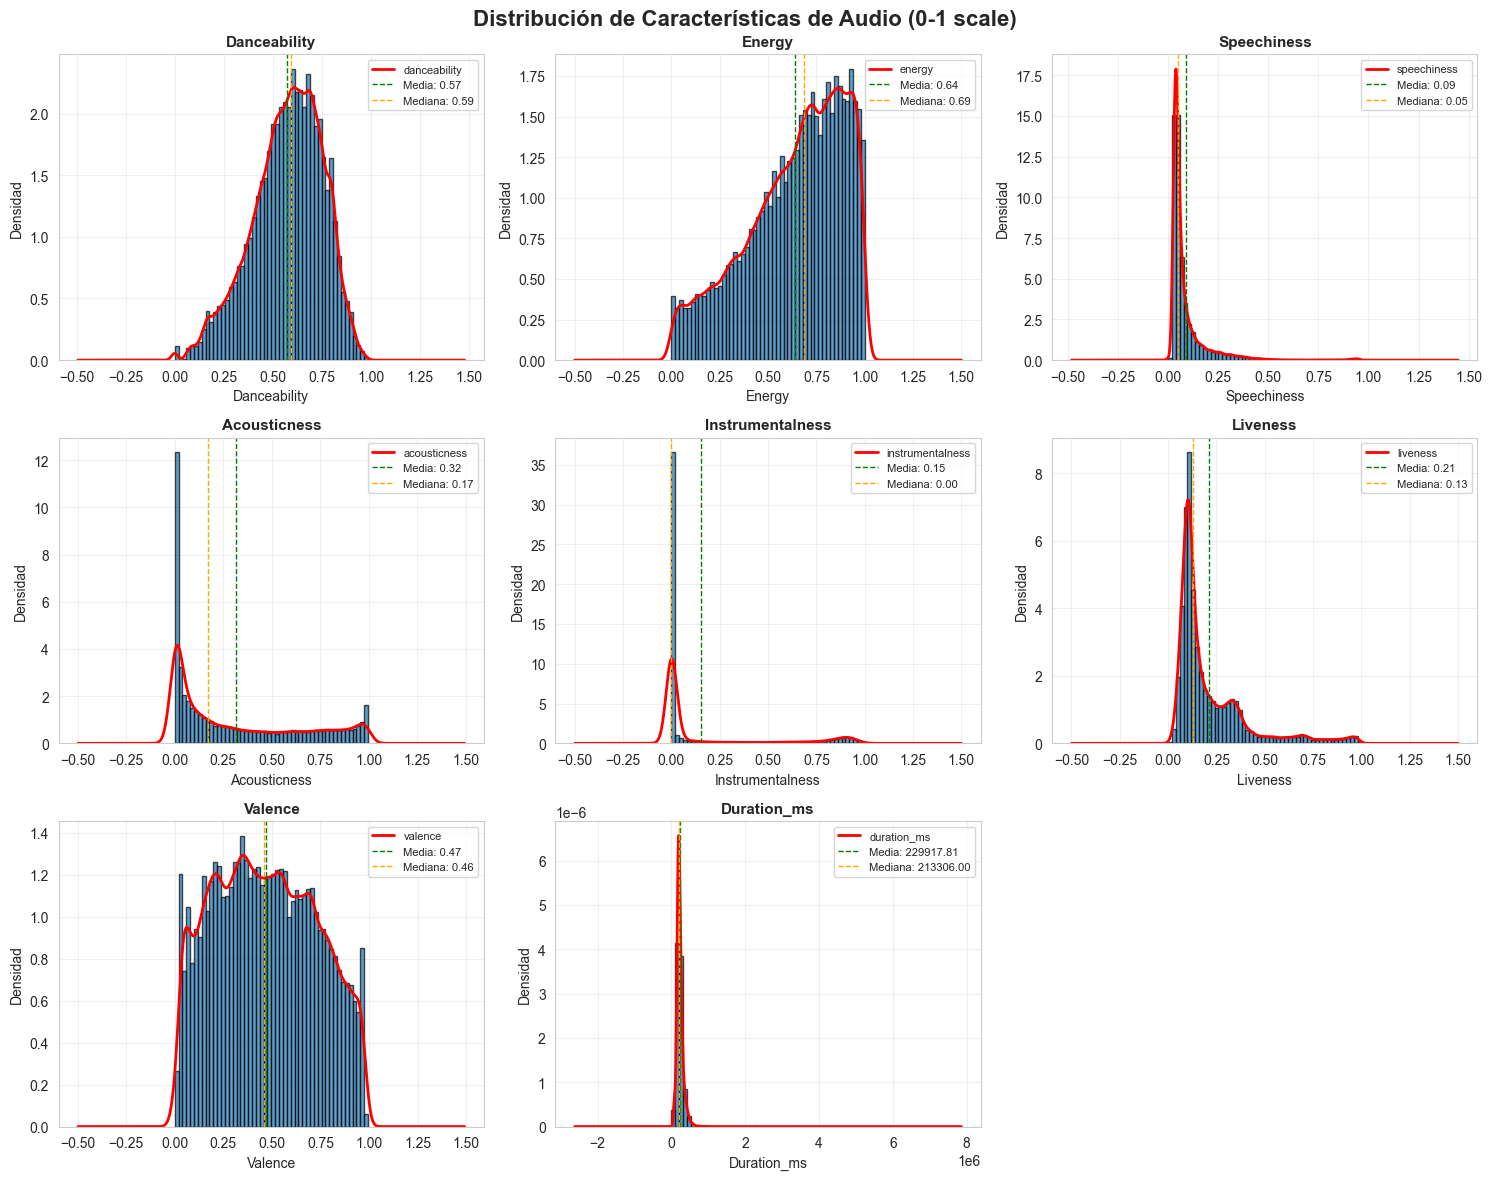

In [61]:
#Distribuciones de las principales características de audio
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'duration_ms']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribución de Características de Audio (0-1 scale)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(audio_features):
    row = idx // 3
    col = idx % 3
    
    #Histograma con curva de densidad
    axes[row, col].hist(df[feature], bins=50, alpha=0.7, edgecolor='black', density=True)
    df[feature].plot(kind='kde', ax=axes[row, col], color='red', linewidth=2)
    
    axes[row, col].set_xlabel(feature.capitalize(), fontsize=10)
    axes[row, col].set_ylabel('Densidad', fontsize=10)
    axes[row, col].set_title(f'{feature.capitalize()}', fontsize=11, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    
    #Añadir estadísticas en el gráfico
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[row, col].axvline(mean_val, color='green', linestyle='--', linewidth=1, label=f'Media: {mean_val:.2f}')
    axes[row, col].axvline(median_val, color='orange', linestyle='--', linewidth=1, label=f'Mediana: {median_val:.2f}')
    axes[row, col].legend(fontsize=8)

#Eliminar subplots vacíos
for idx in range(len(audio_features), 9):
    row = idx // 3
    col = idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

#### Distribución de Popularidad, Tempo y Ruido

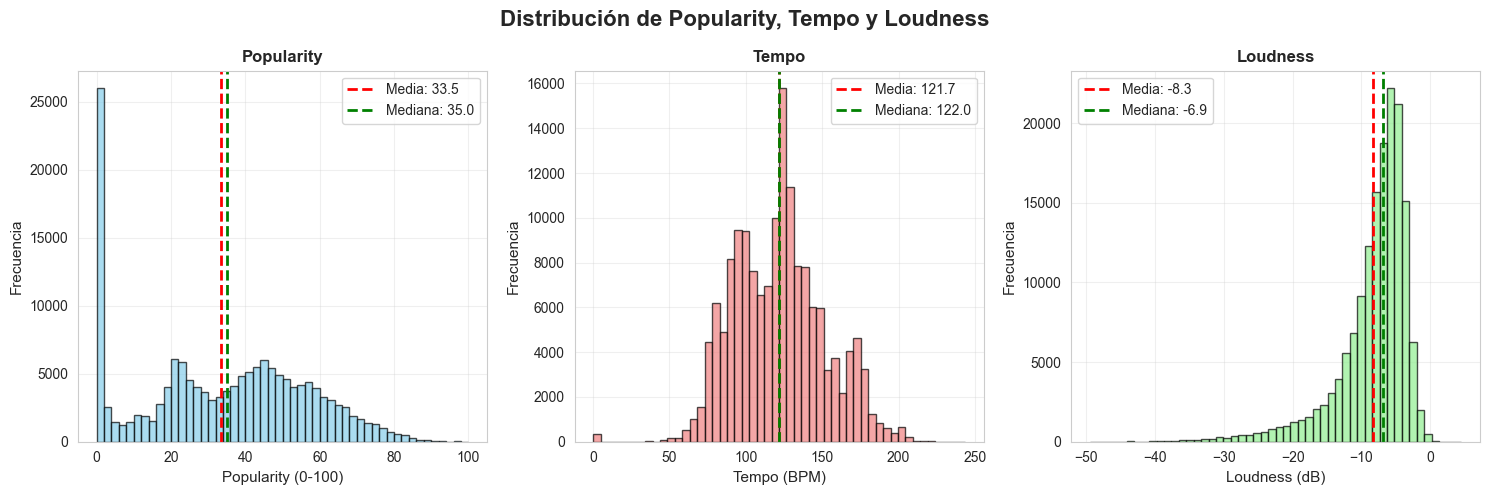

In [62]:
# Distribución de Popularity, Tempo y Loudness
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de Popularity, Tempo y Loudness', fontsize=16, fontweight='bold')

# Popularity
axes[0].hist(df['popularity'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Popularity (0-100)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Popularity', fontsize=12, fontweight='bold')
axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {df['popularity'].mean():.1f}")
axes[0].axvline(df['popularity'].median(), color='green', linestyle='--', linewidth=2, label=f"Mediana: {df['popularity'].median():.1f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tempo
axes[1].hist(df['tempo'], bins=50, alpha=0.7, edgecolor='black', color='lightcoral')
axes[1].set_xlabel('Tempo (BPM)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Tempo', fontsize=12, fontweight='bold')
axes[1].axvline(df['tempo'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {df['tempo'].mean():.1f}")
axes[1].axvline(df['tempo'].median(), color='green', linestyle='--', linewidth=2, label=f"Mediana: {df['tempo'].median():.1f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Loudness
axes[2].hist(df['loudness'], bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
axes[2].set_xlabel('Loudness (dB)', fontsize=11)
axes[2].set_ylabel('Frecuencia', fontsize=11)
axes[2].set_title('Loudness', fontsize=12, fontweight='bold')
axes[2].axvline(df['loudness'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {df['loudness'].mean():.1f}")
axes[2].axvline(df['loudness'].median(), color='green', linestyle='--', linewidth=2, label=f"Mediana: {df['loudness'].median():.1f}")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de correlaciones

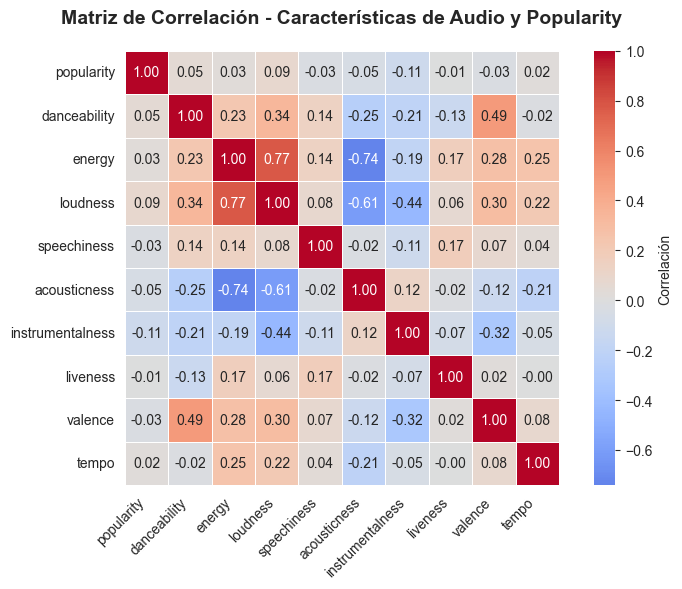

In [63]:
# Matriz de correlación entre variables numéricas
# Esto ayuda a identificar relaciones entre características

correlation_features = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                        'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

correlation_matrix = df[correlation_features].corr()

# Crear mapa de calor de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True,          # Mostrar valores
            fmt='.2f',           # Formato de 2 decimales
            cmap='coolwarm',     # Esquema de colores: azul (negativo) a rojo (positivo)
            center=0,            # Centrar en 0
            square=True,         # Celdas cuadradas
            linewidths=0.5,
            cbar_kws={'label': 'Correlación'})

plt.title('Matriz de Correlación - Características de Audio y Popularity', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



**Interpretación del mapa de calor**
- Valores cercanos a +1 (rojo): correlación positiva fuerte
- Valores cercanos a -1 (azul): correlación negativa fuerte
- Valores cercanos a 0 (blanco): sin correlación


### Análisis de outliers (valores atípicos)

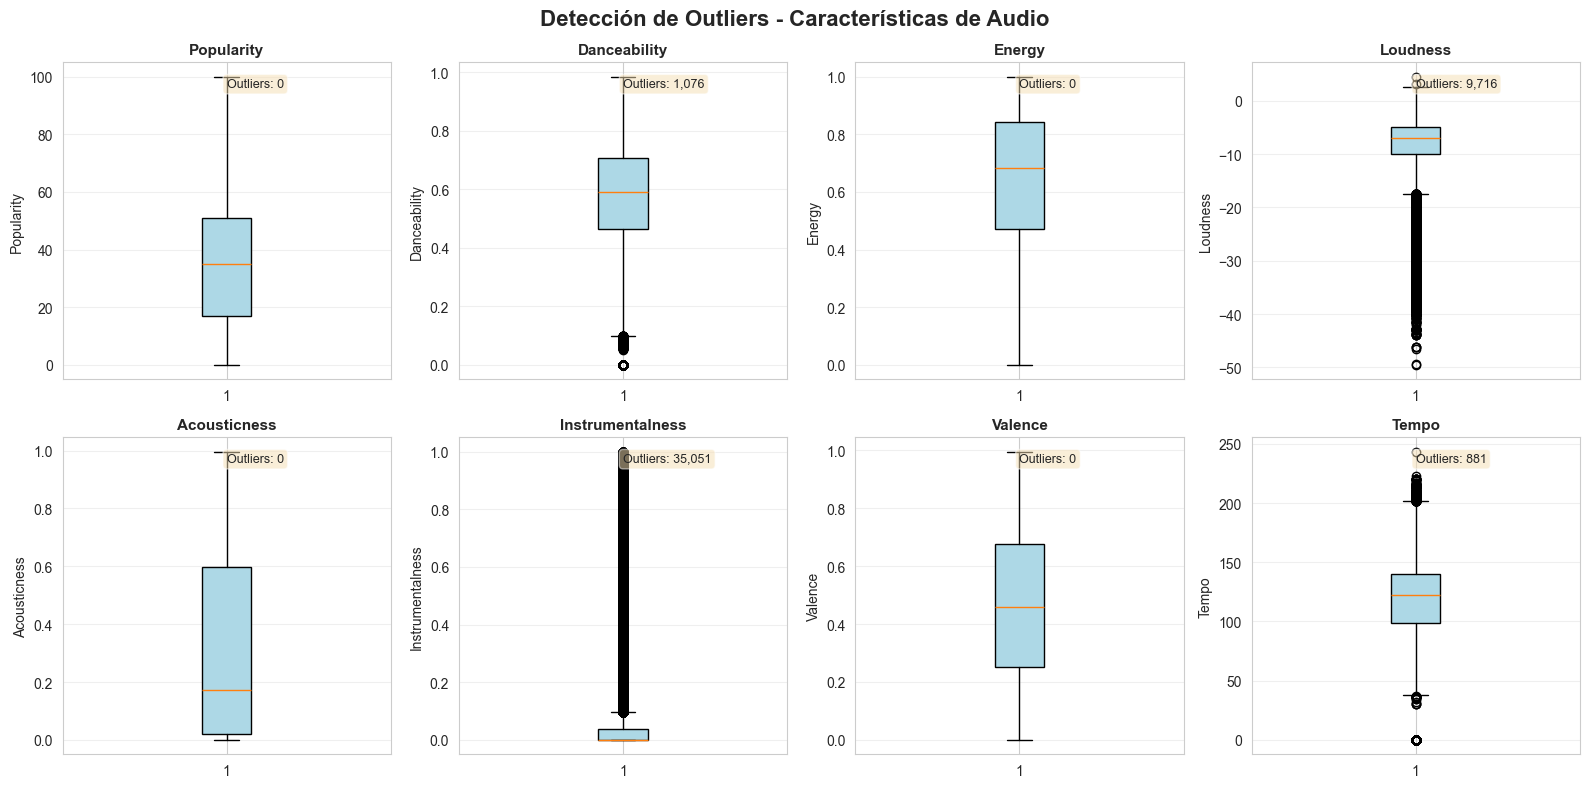

In [64]:
# Box plots para detectar outliers en características de audio
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Detección de Outliers - Características de Audio', fontsize=16, fontweight='bold')

features_for_outliers = ['popularity', 'danceability', 'energy', 'loudness', 
                         'acousticness', 'instrumentalness', 'valence', 'tempo']

for idx, feature in enumerate(features_for_outliers):
    row = idx // 4
    col = idx % 4
    
    # Crear box plot
    bp = axes[row, col].boxplot(df[feature], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_edgecolor('black')
    
    axes[row, col].set_ylabel(feature.capitalize(), fontsize=10)
    axes[row, col].set_title(feature.capitalize(), fontsize=11, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    # Calcular y mostrar número de outliers
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    
    axes[row, col].text(0.5, 0.95, f'Outliers: {len(outliers):,}', 
                        transform=axes[row, col].transAxes,
                        fontsize=9, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## Preguntas y problemas

Se plantearon las siguientes preguntas de investigación:

 1. ¿Es posible predecir la popularidad de una canción a partir de sus características musicales?

 2. ¿Existen grupos naturales de canciones que compartan características similares, independientemente de su género declarado?

 3. ¿Es posible predecir el género de una canción a partir de sus características de audio como energía, tempo o bailabilidad?

## Propuesta Metodológica Experimental

Para responder las preguntas anteriores, se propusieron las siguientes metodologías:

**Pregunta 1: Predicción de popularidad**
Tiene como objetivo predecir la popularidad a partir de las características de una canción, el cual se abordó a partir de dos enfoques:
 - Regresión (popularidad como variable numérica):
   * Modelos: Regresión lineal, Random Forest (regresor).
   * Métricas: R² (coeficiente de determinación), MAE (Error absoluto medio).

 - Clasificación (popularidad como categorías):
   * Se creó una variable categórica a partir de "popularity", con tres niveles: "Poco popular", "Popular", "Muy popular".
   * Modelo: Random Forest Classifier.
   * Métricas: Accuracy, Matriz de confusión.

**Pregunta 2: Agrupación natural**
Tiene como objetivo encontrar agrupaciones naturales en el espacio de características musicales.
 - Preprocesamiento: Reducción de dimensionalidadm, para reducir el ruido y eliminar columnas muy correlacionadas.
 - Algoritmo utilizado: K-means.
 - Métricas: Inercia, Silhouette Score.

**Pregunta 3: Predicción de género**
Tiene como objetivo predecir el género a partir de las características de una canción.
 - Modelos utilizados: Random Forest, XGBoost, Redes Neuronales, ya que los modelos que utilizan arboles de decisión suelen resolver bien este tipo de problemas. Por otro lados, las redes neuronales podrían generar muy buenos resultados en comparación a otros modelos, al haber tantas clases.
 - Métricas: Accuracy, Matriz de confusión, lo cual es suficiente, ya que las clases (géneros musicales) están equilibradas, es decir, cada una posee la misma cantidad de datos.
 - Optimización: Grid Search para elegir los mejores hiperparámetros de cada modelo.

**Preprocesamiento general:**

 - Eliminación de duplicados, para evitar errores.
 - División de datos en train/test.
 - Codificación de género (Label Encoding o One-Hot Encoding), para que se pueda utilizar como clase o como característica.
 - Normalización de columnas de características si es necesario, para que cada característica constribuya equitativa y no afecte los resultados.

## Experimento preliminar

Para evaluar la capacidad de distintos modelos de aprendizaje automático en la predicción de la popularidad de canciones de Spotify, se realizaron experimentos iniciales con enfoques de regresión y clasificación.

### 1. Regresión lineal
Se entrenó un modelo de regresión lineal tomando como variable dependiente la popularidad (escala 0–100) y como variables explicativas las características numéricas y categóricas de cada canción (duración, métricas de audio, indicador de explicit content y género musical).
Métricas de evaluación:

Error Absoluto Medio (MAE): 14.07
Coeficiente de Determinación (R²): 0.26

Estos valores indican que el modelo lineal captura parcialmente la variabilidad de la popularidad, pero con un desempeño limitado, probablemente por la relación no lineal entre las variables.

### 2. Random Forest Regressor
Para mejorar la capacidad predictiva, se utilizó un modelo de bosques aleatorios de regresión.
Métricas obtenidas:

MAE: 10.40
R²: 0.52
Tiempo de entrenamiento: ~1 minuto 20 segundos.

Este modelo mostró una mejora significativa frente a la regresión lineal, sugiriendo que los métodos no lineales capturan mejor la complejidad de los datos, pese a un incremento en la duración de entrenamiento.

### 3. Random Forest Classifier
Finalmente, se reformuló el problema como clasificación, dividiendo las canciones en tres categorías según popularidad: Poco Popular (0–40), Popular (41–60) y Muy Popular (61–100). Para lo que se obtuvo:
Precisión global (Accuracy): 0.77

Reporte de clasificación:
Poco Popular: precision 0.79, recall 0.92, f1-score 0.85
Popular: precision 0.73, recall 0.61, f1-score 0.66
Muy Popular: precision 0.73, recall 0.41, f1-score 0.52

Tiempo de entrenamiento: ~12 segundos con procesamiento paralelo.

Con esto, se evidencia que el modelo clasificador logra un desempeño aceptable, destacando su mayor capacidad para identificar canciones Poco Populares. Sin embargo, presenta menor recall en la categoría Muy Popular, indicando dificultad para distinguir canciones de alta popularidad, lo cual es posible se deba a la existencia de algún desbalance de clases.

A partir de esto, es posible decir que los experimentos iniciales muestran que los modelos basados en Random Forest superan ampliamente a la regresión lineal tanto en predicción continua como en clasificación. Asimismo, la tarea de clasificación resulta más prometedora, con un 77% de precisión general, aunque aún presenta desafíos en la predicción de canciones altamentee populares.


## Anexo

Resolución experimento preliminar pregunta "¿Es posible predecir la popularidad de una canción a partir de sus características musicales?"

Regresión lineal para predecir popularidad a partir de métricas sobre la canción, sin considerar el nombre del artista.

In [22]:
# Carga de datos
file_name = 'dataset.csv'
df = pd.read_csv(file_name)
df['explicit'] = df['explicit'].astype(int)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=666)

features_to_use = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre'
]
# sets entrenamiento y prueba
y_train = train_df['popularity']
y_test = test_df['popularity']

X_train = train_df[features_to_use]
X_test = test_df[features_to_use]
# convertimos columnas de género en columnas numéricas
X_train= pd.get_dummies(X_train, columns=['track_genre'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['track_genre'], drop_first=True)


# forzamos a que ambos conjuntos tengan las mismas columnas de género

train_cols = X_train.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0
X_test = X_test[train_cols] # asegura el mismo orden



linear_model = LinearRegression(n_jobs=-1)
linear_model.fit(X_train, y_train)
predictions = linear_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Error Absoluto Medio (MAE): {mae}")
print(f"Coeficiente de Determinación (R²): {r2}")

Error Absoluto Medio (MAE): 14.07172419404308
Coeficiente de Determinación (R²): 0.2615407333800547


Probamos con random forest regressor

In [19]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor


rf_regressor = RandomForestRegressor(n_estimators=100, random_state=666, n_jobs=-1)
rf_regressor.fit(X_train, y_train)

rf_predictions = rf_regressor.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"RandomForestRegressor - MAE: {rf_mae}")
print(f"RandomForestRegressor - R²: {rf_r2}")

#se demoro 1 min 20 segundos en correr

RandomForestRegressor - MAE: 10.403142644859185
RandomForestRegressor - R²: 0.5224642151505604


Ahora estudiamos la populariad usando random forest classifier, para lo cual convertimos la popularidad en categorías

Precisión (Accuracy): 0.7682456140350877

Reporte de Clasificación:
              precision    recall  f1-score   support

 Muy Popular       0.73      0.41      0.52      2714
Poco Popular       0.79      0.92      0.85     13465
     Popular       0.73      0.61      0.66      6621

    accuracy                           0.77     22800
   macro avg       0.75      0.64      0.68     22800
weighted avg       0.76      0.77      0.76     22800


Matriz de Confusión:


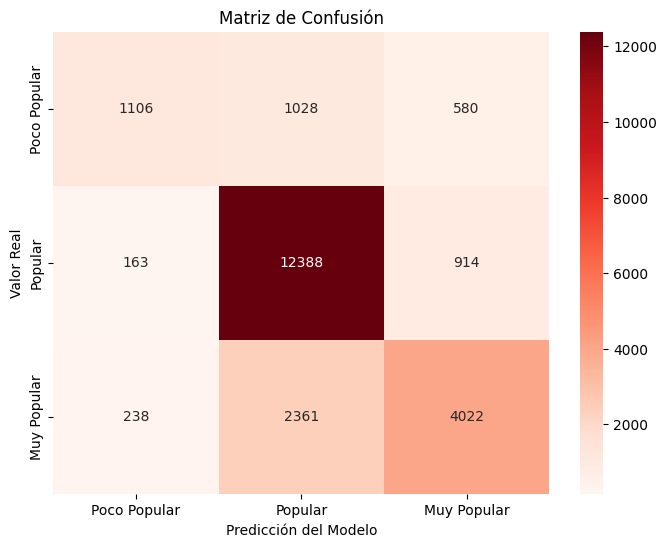

In [ ]:


file_name = 'dataset.csv'
df = pd.read_csv(file_name)
# pasamos explicit a numerico
df['explicit'] = df['explicit'].astype(int)

#le damos una etiqueta a cada cancion segun su popularidad
bins = [-1, 40, 60, 101]
labels = ['Poco Popular', 'Popular', 'Muy Popular']
df['popularity_category'] = pd.cut(df['popularity'], bins=bins, labels=labels)


# usamos stratify para mantener la proporción en train y test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=666, stratify=df['popularity_category'])

features_to_use = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre'
]

# sets entrenamiento y prueba
y_train = train_df['popularity_category']
y_test = test_df['popularity_category']

X_train = train_df[features_to_use]
X_test = test_df[features_to_use]

# convertimos columnas de género en columnas numéricas
X_train = pd.get_dummies(X_train, columns=['track_genre'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['track_genre'], drop_first=True)

# forzamos a que ambos conjuntos tengan las mismas columnas de género
train_cols = X_train.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
X_test = X_test[train_cols] # asegura el mismo orden


clf_model = RandomForestClassifier(n_estimators=100, random_state=666, n_jobs=-1)

clf_model.fit(X_train, y_train)

predictions = clf_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print(f"Precisión (Accuracy): {accuracy}")
print("\nReporte de Clasificación:")
print(report)


print("\nMatriz de Confusión:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt = 'd',cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

#con n_jobs=-1 se demora 12 seg. Con n_jobs=1 se demora 45 seg.

## Contribución en el informe

-Juan Balboa E.         Redacción Experimento Preliminar, co-resolución pregunta sobre popularidad.


-Sebastián Cadena A.    Redacción Propuesta Experimental, Organización del código, co-resolución pregunta sobre popularidad.


-Benjamín Fuentes R.    Redacción preguntas y problemas, Redacción Introducción, co-resolución pregunta sobre popularidad.


-Matías Méndez Z.       Redacción informe, co-resolución pregunta sobre popularidad, co-resolución pregunta sobre popularidad.


-Camila Rojas G.        Redacción Exploración de datos, Revisión Informe, co-resolución pregunta sobre popularidad.
